# 🔆 Overview
This notebook imports minute level synthetic data, builds the logistic regression model with Leave-One-Dog-Out Cross Validation for multiclass classification.

Here, we predict the glucose status of current using x minutes data that n-minute ahead of now.

# 🔆 Setup / Import Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os


from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.utils import resample
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import LeaveOneGroupOut

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    accuracy_score,
    ConfusionMatrixDisplay
)

In [2]:
# mounting on gdrive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# import data
# WooJung
data_path = "/content/drive/MyDrive/DATASCI210/210 Capstone/final_data/updated"

# Ainsley


# Ci
# data_path = "/content/drive/MyDrive/210 Capstone/final_data/updated"

Based on the EDA, Canine 1 has more completed cases for both Hyper and Hypo and we want to use Canine 1 as the test set; and Canine 2-5 as the train set to run the LODO cross validation.

In [4]:
# import train df: canine 2 - 6
file_train_df = os.path.join(data_path, "train_onset_final_0329.csv")
raw_train_df = pd.read_csv(file_train_df)

raw_train_df.head()

,dogID,ID,timestamp,glucose,glucose_category,unsafe,observed,onset,onset_observed,split
0,canine2,canine2-001,2025-04-09 12:56:00,308.000000,hyperglycemia,True,True,False,False,train
1,canine2,canine2-001,2025-04-09 12:57:00,305.615730,hyperglycemia,True,False,False,False,train
2,canine2,canine2-001,2025-04-09 12:58:00,303.471173,hyperglycemia,True,False,False,False,train
3,canine2,canine2-001,2025-04-09 12:59:00,301.876377,hyperglycemia,True,False,False,False,train
4,canine2,canine2-001,2025-04-09 13:00:00,298.388740,hyperglycemia,True,False,False,False,train


In [5]:
# import test df: canine 1
file_test_df = os.path.join(data_path, "test_onset_final_0329.csv")
raw_test_df = pd.read_csv(file_test_df)
raw_test_df.head()

,dogID,ID,timestamp,glucose,glucose_category,unsafe,observed,onset,onset_observed,split
0,canine1,canine1-001,2025-11-01 05:51:00,375.000000,hyperglycemia,True,True,False,False,test
1,canine1,canine1-001,2025-11-01 05:52:00,375.056846,hyperglycemia,True,False,False,False,test
2,canine1,canine1-001,2025-11-01 05:53:00,374.714980,hyperglycemia,True,False,False,False,test
3,canine1,canine1-001,2025-11-01 05:54:00,375.045685,hyperglycemia,True,False,False,False,test
4,canine1,canine1-001,2025-11-01 05:55:00,375.676269,hyperglycemia,True,False,False,False,test


In [6]:
print("In Train Set:")
print(raw_train_df['dogID'].value_counts().to_string())
print("In Test Set:")
print(raw_test_df['dogID'].value_counts().to_string())

In Train Set:
dogID
canine6    178346
canine5     70271
canine3     62608
canine4     32281
canine2     13227
In Test Set:
dogID
canine1    36618


# 🔆 Feature Engineering

Next we're going to build engineered features from a historical window that ends `ahead_minutes` before the target time:

history_minutes=30, ahead_minutes=15

-> use [t-45, t-15) to predict target at t

In [7]:
def feature_engineering_minute_ahead(
    df,
    history_minutes=30,
    ahead_minutes=15,
    glucose_col="glucose",
    # for multiclass, unsafe is changed to glucose_category
    target_col = "glucose_category",
    dog_col="dogID",
    segment_col="ID",
    time_col="timestamp"
):
    """
    Build engineered features from minute-level synthetic data.

    For each target time t:
      - use a history window of length `history_minutes`
      - the history window ends `ahead_minutes` before t
      - predict target_col at time t

    Example:
      history_minutes = 30, ahead_minutes = 10
      -> use [t-40, t-10) to predict status at t
    """

    features = []

    # Group by ID so each window stays inside the subset
    for seg_id, group in df.groupby(segment_col, sort=False):
        dog = group[dog_col].iloc[0]

        # Convert needed columns to NumPy arrays for faster slicing
        glucose = group[glucose_col].astype(float).to_numpy()
        timestamps = pd.to_datetime(group[time_col]).to_numpy()
        targets = group[target_col]

        n = len(group)

        # Earliest valid target index:
        # we need enough earlier rows to cover both history and ahead gap
        start_i = history_minutes + ahead_minutes

        for i in range(start_i, n):
            # Window layout:
            #   target row = i
            #   history ends at i - ahead_minutes (exclusive)
            hist_end = i - ahead_minutes
            hist_start = hist_end - history_minutes

            # Slice the glucose history window and its timestamps
            g = glucose[hist_start:hist_end]
            ts_window = timestamps[hist_start:hist_end]

            # Require a full history window
            if len(g) < history_minutes:
                continue

            # Summary statistics from the history window
            min_glucose = np.min(g)
            max_glucose = np.max(g)
            first_glucose = g[0]
            last_glucose = g[-1]

            # Unweighted mean of glucose values
            mean_glucose = np.mean(g)

            # Slope feature:
            # overall change across the window, scaled by history_minutes
            slope = (last_glucose - first_glucose) / history_minutes

            # Mean gap between consecutive timestamps in the history window
            # This should be 1 for minute-level synthetic data
            gap_minutes = np.diff(ts_window) / np.timedelta64(1, "m")
            mean_gap = gap_minutes.mean()

            # Number of readings used in this history window
            num_readings = len(g)

            # Store one feature row for this target time t
            features.append({
                segment_col: seg_id,          # subset ID / continuous segment
                dog_col: dog,                 # dog identifier for LODO later
                time_col: timestamps[i],      # target time t

                "history_minutes": history_minutes,
                "ahead_minutes": ahead_minutes,

                "mean_glucose": mean_glucose,
                "min_glucose": min_glucose,
                "max_glucose": max_glucose,
                "slope": slope,
                "last_glucose": last_glucose,
                "mean_gap": mean_gap,
                "num_readings": num_readings,

                # actual glucose level at time t
                "glucose": glucose[i],

                # target at time t
                # changed to accommodate multiclass
                target_col: targets.iloc[i]
            })

    return pd.DataFrame(features)

In [8]:
# Build one feature table for one setting
train_feat_df = feature_engineering_minute_ahead(
    df=raw_train_df,
    history_minutes=30,
    ahead_minutes=15
)

test_feat_df = feature_engineering_minute_ahead(
    df=raw_test_df,
    history_minutes=30,
    ahead_minutes=15
)

In [9]:
display(train_feat_df.head(3))
train_feat_df[train_feat_df["glucose_category"] == "normal"].head(3)

,ID,dogID,timestamp,history_minutes,ahead_minutes,mean_glucose,min_glucose,max_glucose,slope,last_glucose,mean_gap,num_readings,glucose,glucose_category
0,canine2-001,canine2,2025-04-09 13:41:00,30,15,280.147356,264.476275,308.000000,-1.450791,264.476275,1.0,30,257.000000,hyperglycemia
1,canine2-001,canine2,2025-04-09 13:42:00,30,15,278.680689,264.000000,305.615730,-1.387191,264.000000,1.0,30,257.691435,hyperglycemia
2,canine2-001,canine2,2025-04-09 13:43:00,30,15,277.287060,263.806835,303.471173,-1.322145,263.806835,1.0,30,259.248454,hyperglycemia


,ID,dogID,timestamp,history_minutes,ahead_minutes,mean_glucose,min_glucose,max_glucose,slope,last_glucose,mean_gap,num_readings,glucose,glucose_category
62,canine2-001,canine2,2025-04-09 14:43:00,30,15,265.457851,261.902988,268.0,0.116202,265.879705,1.0,30,249.215998,normal
63,canine2-001,canine2,2025-04-09 14:44:00,30,15,265.534885,261.902988,268.0,0.042743,264.704678,1.0,30,248.353349,normal
64,canine2-001,canine2,2025-04-09 14:45:00,30,15,265.582728,261.902988,268.0,0.003488,264.857689,1.0,30,246.551754,normal


In [10]:
test_feat_df.head()

,ID,dogID,timestamp,history_minutes,ahead_minutes,mean_glucose,min_glucose,max_glucose,slope,last_glucose,mean_gap,num_readings,glucose,glucose_category
0,canine1-001,canine1,2025-11-01 06:36:00,30,15,374.192531,373.098884,375.676269,-0.059466,373.216021,1.0,30,375.000000,hyperglycemia
1,canine1-001,canine1,2025-11-01 06:37:00,30,15,374.125865,373.000000,375.676269,-0.068562,373.000000,1.0,30,374.942513,hyperglycemia
2,canine1-001,canine1,2025-11-01 06:38:00,30,15,374.064314,373.000000,375.676269,-0.050155,373.210330,1.0,30,375.011613,hyperglycemia
3,canine1-001,canine1,2025-11-01 06:39:00,30,15,374.025546,373.000000,375.676269,-0.049792,373.551931,1.0,30,375.112025,hyperglycemia
4,canine1-001,canine1,2025-11-01 06:40:00,30,15,374.020021,373.000000,375.676269,-0.026545,374.879921,1.0,30,375.317945,hyperglycemia


Sanity Check

In [11]:
# check 'mean_gap' should be 1
print(train_feat_df['mean_gap'].describe())
print(test_feat_df['mean_gap'].describe())


count    344763.0
mean          1.0
std           0.0
min           1.0
25%           1.0
50%           1.0
75%           1.0
max           1.0
Name: mean_gap, dtype: float64
count    35673.0
mean         1.0
std          0.0
min          1.0
25%          1.0
50%          1.0
75%          1.0
max          1.0
Name: mean_gap, dtype: float64


In [12]:
# Timestamp comparison after applying the lookback window
# feat_df_min_timestamp should be "history_minutes+ahead_minutes" after the df_min_timestamp

# Get min/max timestamps from df
df_time_summary = raw_train_df.groupby('ID')['timestamp'].agg(['min', 'max']).rename(columns={'min': 'df_min_timestamp', 'max': 'df_max_timestamp'})

# Get min/max timestamps from feat_df
feat_df_time_summary = train_feat_df.groupby('ID')['timestamp'].agg(['min', 'max']).rename(columns={'min': 'feat_df_min_timestamp', 'max': 'feat_df_max_timestamp'})

# Merge the summaries for comparison
comparison_df = pd.merge(df_time_summary, feat_df_time_summary, on='ID', how='outer')

print("Min/Max Timestamps Comparison by ID:")
display(comparison_df.head())

Min/Max Timestamps Comparison by ID:


,df_min_timestamp,df_max_timestamp,feat_df_min_timestamp,feat_df_max_timestamp
ID,,,,
canine2-001,2025-04-09 12:56:00,2025-04-10 23:58:00,2025-04-09 13:41:00,2025-04-10 23:58:00
canine2-002,2025-04-11 00:58:00,2025-04-11 22:17:00,2025-04-11 01:43:00,2025-04-11 22:17:00
canine2-003,2025-04-12 00:31:00,2025-04-12 11:03:00,2025-04-12 01:16:00,2025-04-12 11:03:00
canine2-004,2025-04-12 13:49:00,2025-04-13 23:36:00,2025-04-12 14:34:00,2025-04-13 23:36:00
canine2-005,2025-04-14 00:36:00,2025-04-14 11:33:00,2025-04-14 01:21:00,2025-04-14 11:33:00


#🔆 Logistic Regression
Multiclass classification Logistic Regression model with Leave-One-Dog-Out

## ⭐ Model Train

In [13]:
def run_lodo_logistic_regression(
    train_df,
    feature_cols,
    # changed for multiclass classification
    target_col="glucose_category",
    group_col="dogID",
    # threshold=0.5, # commenting this out for multiclass
    class_weight="balanced",
    random_state=42,
    max_iter=2000,
    C = 1.0
):
    """
    Run Leave-One-Dog-Out multiclass logistic regression.

    Returns:
    - fold_df: metrics for each held-out dog
    - overall: mean fold-level metrics so each dog has equal weight
    - confusion_matrices: dict of confusion matrices by held-out dog
    """


    model_df = train_df.copy()

    X = model_df[feature_cols]
    # y = model_df[target_col].astype(int)
    groups = model_df[group_col]


    le = LabelEncoder()
    y = pd.Series(le.fit_transform(model_df[target_col]), index = model_df.index)
    class_names = list(le.classes_)

    logo = LeaveOneGroupOut()

     # Simple pipeline: scale, then fit logistic regression
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            C = C,
            max_iter=max_iter,
            class_weight=class_weight,
            random_state=random_state))
    ])

    fold_results = []
    confusion_matrices = {}

    # Hold out one dog each time
    for train_idx, val_idx in logo.split(X, y, groups):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
        val_dog = groups.iloc[val_idx].iloc[0]

        model.fit(X_train, y_train)

        # Probability of unsafe_now = 1
        # y_prob = model.predict_proba(X_val)[:, 1]
        # y_pred = (y_prob >= threshold).astype(int)

        y_pred = model.predict(X_val)
        y_prob = model.predict_proba(X_val)

        fold_result = {
            "val_dog": val_dog,
            "n_val": len(y_val),
            "accuracy": accuracy_score(y_val, y_pred),
            "precision_macro": precision_score(y_val, y_pred, average= "macro", zero_division=0),
            "recall_macro": recall_score(y_val, y_pred, average = "macro", zero_division = 0),
            "f1_macro": f1_score(y_val, y_pred, average = "macro", zero_division = 0),
            "precision_weighted": precision_score(y_val, y_pred, average = "weighted", zero_division = 0),
            "recall_weighted": recall_score(y_val, y_pred, average = "weighted", zero_division = 0),
            "f1_weighted": f1_score(y_val, y_pred, average = "weighted", zero_division = 0)
        }

        # multiclass ROC-AUC can fall if the held-out dog does not contain all classes
        try:
            fold_result["roc_auc_ovr"] = roc_auc_score(
                y_val, y_prob,
                multi_class = "ovr",
                average = "macro")

        except ValueError:
            fold_result["roc_auc_ovr"] = np.nan

        fold_results.append(fold_result)

        cm = confusion_matrix(y_val, y_pred, labels = range(len(class_names)))
        confusion_matrices[val_dog] = pd.DataFrame(cm, index = class_names, columns = class_names)

    fold_df = pd.DataFrame(fold_results)

    overall = {
        "accuracy": fold_df["accuracy"].mean(),
        "precision": fold_df["precision_macro"].mean(),
        "recall": fold_df["recall_macro"].mean(),
        "f1": fold_df["f1_macro"].mean(),
        "precision_weighted": fold_df["precision_weighted"].mean(),
        "recall_weighted": fold_df["recall_weighted"].mean(),
        "roc_auc": fold_df["roc_auc_ovr"].mean(skipna = True)
    }

    return fold_df, overall, confusion_matrices, class_names

In [14]:
feature_cols = [
    "mean_glucose",
    "min_glucose",
    "max_glucose",
    "slope",
    "last_glucose",
]

fold_df, overall, confusion_matrices, class_names = run_lodo_logistic_regression(
    train_df=train_feat_df,
    feature_cols=feature_cols,
    target_col="glucose_category",
    group_col="dogID",
    # threshold=0.5
)

print("Training LODO results:")
print(fold_df)

Training LODO results:
   val_dog   n_val  accuracy  precision_macro  recall_macro  f1_macro  \
0  canine2   12867  0.842465         0.716883      0.903756  0.729945   
1  canine3   60538  0.965807         0.650904      0.793701  0.654196   
2  canine4   31471  0.961329         0.643631      0.614691  0.628250   
3  canine5   69461  0.966600         0.673056      0.962197  0.697380   
4  canine6  170426  0.950330         0.688346      0.951752  0.720013   

   precision_weighted  recall_weighted  f1_weighted  roc_auc_ovr  
0            0.926849         0.842465     0.871360     0.976837  
1            0.976473         0.965807     0.971000     0.982461  
2            0.968760         0.961329     0.964537          NaN  
3            0.976727         0.966600     0.971125     0.996007  
4            0.966103         0.950330     0.957054     0.994065  


In [15]:
print("=== LODO Logistic Regression Overall Training Result ===")
print(f"Accuracy : {overall['accuracy']:.3f}")
print(f"Precision: {overall['precision']:.3f}")
print(f"Recall   : {overall['recall']:.3f}")
print(f"F1       : {overall['f1']:.3f}")
print(f"ROC-AUC  : {overall['roc_auc']:.3f}")

=== LODO Logistic Regression Overall Training Result ===
Accuracy : 0.937
Precision: 0.675
Recall   : 0.845
F1       : 0.686
ROC-AUC  : 0.987


In [18]:
print("Row = actual / Column = predicted")
print("ex) canine2: 348 hyperglycemic events were predicted as normal")
for dog, cm in confusion_matrices.items():
    print(f"\nConfusion Matrix for {dog}")
    print(cm)

Row = actual / Column = predicted
ex) canine2: 348 hyperglycemic events were predicted as normal

Confusion Matrix for canine2
               hyperglycemia  hypoglycemia  normal
hyperglycemia           3978             0     348
hypoglycemia               0           480       0
normal                   152          1527    6382

Confusion Matrix for canine3
               hyperglycemia  hypoglycemia  normal
hyperglycemia          42938             0     961
hypoglycemia               0            15      17
normal                   403           689   15515

Confusion Matrix for canine4
               hyperglycemia  hypoglycemia  normal
hyperglycemia           4792             0     772
hypoglycemia               0             0       0
normal                   198           247   25462

Confusion Matrix for canine5
               hyperglycemia  hypoglycemia  normal
hyperglycemia          54865             0    1046
hypoglycemia               0            97       0
normal            

## ⭐ Fine-tuning

1. C: regularization
  * small C: simpler / less overfitting / more bias
  * large C: fits to the data more closely / more flexible / higher risk of overfitting

In [ ]:
C_values = [0.0001, 0.001, .01, .1, 1, 10, 100]
results = []

for C in C_values:
  fold_df, overall, _, _ = run_lodo_logistic_regression(
      train_df=train_feat_df,
      feature_cols=feature_cols,
      target_col = "glucose_category",
      group_col = "dogID",
      C = C
      )
  overall["C"] = C
  results.append(overall)


tuning_df = pd.DataFrame(results).round(3)
tuning_df.sort_values("f1", ascending = False)

,accuracy,precision,recall,f1,precision_weighted,recall_weighted,roc_auc,C
6,0.938,0.675,0.850,0.687,0.963,0.938,0.987,100.000
5,0.938,0.675,0.850,0.687,0.963,0.938,0.987,10.000
4,0.937,0.675,0.845,0.686,0.963,0.937,0.987,1.000
3,0.933,0.671,0.840,0.682,0.960,0.933,0.987,0.100
2,0.929,0.666,0.825,0.674,0.957,0.929,0.985,0.010
1,0.917,0.658,0.821,0.659,0.953,0.917,0.982,0.001
0,0.887,0.643,0.812,0.631,0.941,0.887,0.976,0.000


👉 Let's not touch on C...

2. Tune class-specific probability thresholds
* Since the main target is hypoglycemic events, it might be better to set a probability that is more lenient towards predicting hypoglycemia

In [19]:
def predict_with_thresholds(probs, class_names, t_hypo = .3, t_hyper = .3):
  class_to_idx = {c: i for i, c in enumerate(class_names)}

  idx_hypo = class_to_idx["hypoglycemia"]
  idx_hyper = class_to_idx["hyperglycemia"]
  idx_normal = class_to_idx["normal"]

  y_pred = []

  for p in probs:
    p_hypo = p[idx_hypo]
    p_hyper = p[idx_hyper]
    p_normal = p[idx_normal]

    # prioritize unsafe (starting from hypo if they pass threshold)
    if p_hypo >= t_hypo:
      y_pred.append(idx_hypo)
    elif p_hyper >= t_hyper:
      y_pred.append(idx_hyper)
    else:
      y_pred.append(idx_normal)

  return np.array(y_pred)


In [80]:
def run_lodo_logistic_regression(
    train_df,
    feature_cols,
    # changed for multiclass classification
    target_col="glucose_category",
    group_col="dogID",
    # threshold=0.5, # commenting this out for multiclass
    class_weight="balanced",
    random_state=42,
    max_iter=2000,
    # C = 1.0,
    t_hypo = .5,
    t_hyper = .5
):
    """
    Run Leave-One-Dog-Out multiclass logistic regression.

    Returns:
    - fold_df: metrics for each held-out dog
    - overall: mean fold-level metrics so each dog has equal weight
    - confusion_matrices: dict of confusion matrices by held-out dog
    """


    model_df = train_df.copy()

    X = model_df[feature_cols]
    # y = model_df[target_col].astype(int)
    groups = model_df[group_col]


    le = LabelEncoder()
    y = pd.Series(le.fit_transform(model_df[target_col]), index = model_df.index)
    class_names = list(le.classes_)

    logo = LeaveOneGroupOut()

     # Simple pipeline: scale, then fit logistic regression
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            # C = C,
            max_iter=max_iter,
            class_weight=class_weight,
            random_state=random_state))
    ])

    fold_results = []
    confusion_matrices = {}

    # Hold out one dog each time
    for train_idx, val_idx in logo.split(X, y, groups):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
        val_dog = groups.iloc[val_idx].iloc[0]

        model.fit(X_train, y_train)

        # Probability of unsafe_now = 1
        # y_prob = model.predict_proba(X_val)[:, 1]
        # y_pred = (y_prob >= threshold).astype(int)

        # changing this part to use predict_with_thresholds
        y_prob = model.predict_proba(X_val)
        y_pred = predict_with_thresholds(
            y_prob,
            class_names,
            t_hypo = t_hypo,
            t_hyper = t_hyper
        )

        fold_result = {
            "val_dog": val_dog,
            "n_val": len(y_val),
            "accuracy": accuracy_score(y_val, y_pred),
            "precision_macro": precision_score(y_val, y_pred, average= "macro", zero_division=0),
            "recall_macro": recall_score(y_val, y_pred, average = "macro", zero_division = 0),
            "f1_macro": f1_score(y_val, y_pred, average = "macro", zero_division = 0),
            "precision_weighted": precision_score(y_val, y_pred, average = "weighted", zero_division = 0),
            "recall_weighted": recall_score(y_val, y_pred, average = "weighted", zero_division = 0),
            "f1_weighted": f1_score(y_val, y_pred, average = "weighted", zero_division = 0)
        }

        # multiclass ROC-AUC can fall if the held-out dog does not contain all classes
        try:
            fold_result["roc_auc_ovr"] = roc_auc_score(
                y_val, y_prob,
                multi_class = "ovr",
                average = "macro")

        except ValueError:
            fold_result["roc_auc_ovr"] = np.nan

        fold_results.append(fold_result)

        cm = confusion_matrix(y_val, y_pred, labels = range(len(class_names)))
        confusion_matrices[val_dog] = pd.DataFrame(cm, index = class_names, columns = class_names)

    fold_df = pd.DataFrame(fold_results)

    overall = {
        "accuracy": fold_df["accuracy"].mean(),
        "precision": fold_df["precision_macro"].mean(),
        "recall": fold_df["recall_macro"].mean(),
        "f1": fold_df["f1_macro"].mean(),
        "precision_weighted": fold_df["precision_weighted"].mean(),
        "recall_weighted": fold_df["recall_weighted"].mean(),
        "f1_weighted": fold_df["f1_weighted"].mean(),
        "roc_auc": fold_df["roc_auc_ovr"].mean(skipna = True)
    }

    return fold_df, overall, confusion_matrices, class_names

In [74]:
threshold_val = [.2, .3, .4, .5, .6]
# since we prioritize hypo over hyper
# threshold_hyper = [.3, .4, .5, .6, .7]
results = []

for t_hypo in threshold_val:
  for t_hyper in threshold_val:
    fold_df, overall, _, _ = run_lodo_logistic_regression(
        train_df=train_feat_df,
        feature_cols=feature_cols,
        target_col = "glucose_category",
        group_col = "dogID",
        t_hypo = t_hypo,
        t_hyper = t_hyper
        )
    overall["t_hypo"] = t_hypo
    overall["t_hyper"] = t_hyper
    results.append(overall)

tuning_df = pd.DataFrame(results).round(3)

In [75]:
tuning_df.sort_values("f1", ascending = False)

,accuracy,precision,recall,f1,precision_weighted,recall_weighted,f1_weighted,roc_auc,t_hypo,t_hyper
22,0.943,0.680,0.848,0.695,0.965,0.943,0.951,0.987,0.6,0.4
21,0.942,0.678,0.848,0.694,0.964,0.942,0.950,0.987,0.6,0.3
23,0.941,0.679,0.846,0.694,0.963,0.941,0.950,0.987,0.6,0.5
24,0.937,0.676,0.842,0.690,0.960,0.937,0.945,0.987,0.6,0.6
20,0.937,0.674,0.844,0.689,0.960,0.937,0.944,0.987,0.6,0.2
17,0.939,0.676,0.847,0.687,0.965,0.939,0.948,0.987,0.5,0.4
16,0.938,0.674,0.847,0.686,0.964,0.938,0.947,0.987,0.5,0.3
18,0.937,0.675,0.845,0.686,0.963,0.937,0.947,0.987,0.5,0.5
19,0.933,0.671,0.841,0.682,0.959,0.933,0.943,0.987,0.5,0.6
15,0.932,0.670,0.843,0.681,0.960,0.932,0.941,0.987,0.5,0.2


## ⭐ Model Test

From the tuning results, we see [threshold = 0.6 for hypoglycemia and threshold = 0.4 for hypergycemia] set has the highest accuracy and relatively high recall.

Next, we'll fit the model on canine1 and set the t_hypo = .6 and t_hyper = .4.

In [30]:
def fit_and_predict_test(
    train_df,
    test_df,
    feature_cols,
    target_col = "glucose_category",
    class_weight = "balanced",
    random_state = 42,
    max_iter = 2000,
    t_hypo = .6,
    t_hyper = .4):

    """
    Fit multiclass logistic regression on the full training set,
    then predict and evaluate on the separate test set using class-specific probability thresholds
    """

    tran_model_df = train_df.copy()
    test_model_df = test_df.copy()

    X_train = tran_model_df[feature_cols]
    X_test = test_model_df[feature_cols]

    le = LabelEncoder()
    y_train = pd.Series(le.fit_transform(tran_model_df[target_col]), index = tran_model_df.index)
    y_test = pd.Series(le.transform(test_model_df[target_col]), index = test_model_df.index)

    class_names = list(le.classes_)

    model = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            max_iter = max_iter,
            class_weight = class_weight,
            random_state = random_state
        ))
    ])

    model.fit(X_train, y_train)

    # predicted probabilities for all class
    y_prob = model.predict_proba(X_test)

    # custom threshold-based predictions
    y_pred = predict_with_thresholds(
        y_prob,
        class_names,
        t_hypo = t_hypo,
        t_hyper = t_hyper
    )

    # build confusion Matrix
    cm = confusion_matrix(y_test, y_pred, labels = range(len(class_names)))
    cm_df = pd.DataFrame(cm, index = class_names, columns = class_names)

    # metrics
    test_results = {
        "accuracy": accuracy_score(y_test, y_pred),
        "precision_macro": precision_score(y_test, y_pred, average= "macro", zero_division=0),
        "recall_macro": recall_score(y_test, y_pred, average = "macro", zero_division = 0),
        "f1_macro": f1_score(y_test, y_pred, average = "macro", zero_division = 0),

        "precision_weighted": precision_score(y_test, y_pred, average = "weighted", zero_division = 0),
        "recall_weighted": recall_score(y_test, y_pred, average = "weighted", zero_division = 0),
        "f1_weighted": f1_score(y_test, y_pred, average = "weighted", zero_division = 0)
        }

    # roc-auc may fail for multiclass if test set does not contain all classes
    try:
        test_results["roc_auc_ovr"] = roc_auc_score(
            y_test, y_prob,
            multi_class = "ovr",
            average = "macro")

    except ValueError:
        test_results["roc_auc_ovr"] = np.nan


    pred_df = test_model_df.copy()

    # save probability columns by class name
    for i, class_name in enumerate(class_names):
        pred_df[f"prob_{class_name}"] = y_prob[:, i]

    pred_df["y_true_enconded"] = y_test
    pred_df["y_pred_encoded"] = y_pred
    pred_df["y_true"] = le.inverse_transform(y_test)
    pred_df["y_pred"] = le.inverse_transform(y_pred)

    return model, test_results, pred_df, cm_df, class_names

In [31]:
# test on Canine1

model, test_results, pred_df, cm_df, class_names = fit_and_predict_test(
    train_df = train_feat_df,
    test_df = test_feat_df,
    feature_cols = feature_cols,
    target_col = "glucose_category",
    t_hypo = .6,
    t_hyper = .4
)

In [32]:
print(test_results)

{'accuracy': 0.9287135929134079, 'precision_macro': 0.7968803930047811, 'recall_macro': 0.9352722219989934, 'f1_macro': 0.8315606059241402, 'precision_weighted': 0.9510542089736088, 'recall_weighted': 0.9287135929134079, 'f1_weighted': 0.9347128467432663, 'roc_auc_ovr': np.float64(0.9917579956076281)}


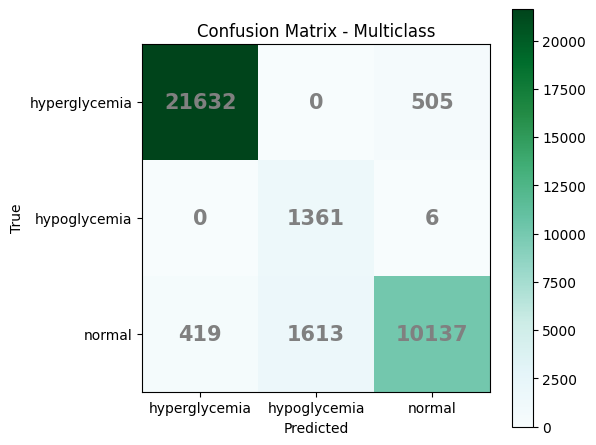

In [70]:
plt.figure(figsize = (6, 5))

plt.imshow(cm_df, interpolation = "nearest", cmap = "BuGn")
plt.title("Confusion Matrix - Multiclass")
plt.colorbar()

# axis labels
plt.xticks(range(len(cm_df.columns)), cm_df.columns)
plt.yticks(range(len(cm_df.index)), cm_df.index)

plt.xlabel("Predicted")
plt.ylabel("True")

for i in range(len(cm_df.index)):
  for j in range(len(cm_df.columns)):
    plt.text(j, i, cm_df.iloc[i, j], ha = "center", va = "center", color = "grey", fontweight = "bold", fontsize = 15)

plt.tight_layout()
plt.show()

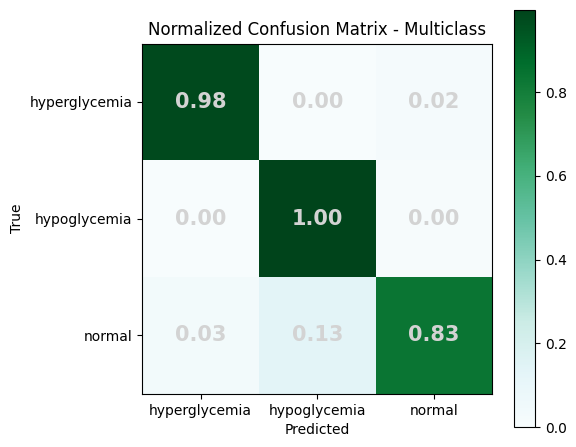

In [72]:
# normalized

cm_norm = cm_df.div(cm_df.sum(axis = 1), axis = 0)

plt.figure(figsize = (6, 5))
plt.imshow(cm_norm, interpolation = "nearest", cmap = "BuGn")
plt.title("Normalized Confusion Matrix - Multiclass")
plt.colorbar()

plt.xticks(range(len(cm_df.columns)), cm_df.columns)
plt.yticks(range(len(cm_df.index)), cm_df.index)

plt.xlabel("Predicted")
plt.ylabel("True")

for i in range(len(cm_df.index)):
  for j in range(len(cm_df.columns)):
    plt.text(j, i, f"{cm_norm.iloc[i, j]:.2f}", ha = "center", va = "center", color = "lightgrey", fontweight = "bold", fontsize = 15)

plt.tight_layout()
plt.show()

#🔆 Shift Time Window

We shift the feature window farther back in time to test how much predictive signal remains in older glucose history. By varying both the **amount of past data** used and **how far** that data is from the target time, we can evaluate how early the model can still predict a dog’s current unsafe status and identify the practical limit of early warning.

In [82]:
def evaluate_history_ahead_grid_lodo(
    raw_train_df,
    history_grid,
    ahead_grid,
    feature_cols,
    glucose_col = "glucose",
    target_col = "glucose_category",
    dog_col = "dogID",
    segment_col = "ID",
    time_col = "timestamp",
    class_weight = "balanced",
    random_state = 42,
    max_iter = 2000,
    t_hypo = .6,
    t_hyper = .4):

    """
    Compare different history/ahead settings using training dogs only.

    For each (history_minutes, ahead_minutes), this function:
      1. builds engineered features from raw training data
      2. runs leave-one-dog-out multiclass logistic regression
      3. saves average fold-level metrics

    Returns result_df (one row per setting)
    """

    results = []

    for history_minutes in history_grid:
        for ahead_minutes in ahead_grid:
            print(f"Running LODO for history = {history_minutes}, ahead = {ahead_minutes}")

            # build engineered features for this history/ahead setting
            train_feat_df = feature_engineering_minute_ahead(
                df = raw_train_df,
                history_minutes = history_minutes,
                ahead_minutes = ahead_minutes,
                glucose_col = glucose_col,
                target_col = target_col,
                dog_col = dog_col,
                segment_col = segment_col,
                time_col = time_col
            )

            fold_df, overall, confusion_matrices, class_names = run_lodo_logistic_regression(
                train_df = train_feat_df,
                feature_cols = feature_cols,
                target_col = target_col,
                group_col = dog_col,
                class_weight = class_weight,
                random_state = random_state,
                max_iter = max_iter,
                t_hypo = t_hypo,
                t_hyper = t_hyper
            )

            results.append({
                "history_minutes": history_minutes,
                "ahead_minutes": ahead_minutes,
                "n_samples": len(train_feat_df),
                "accuracy": overall["accuracy"],
                "precision": overall["precision"],
                "recall": overall["recall"],
                "f1": overall["f1"],

                "precision_weighted": overall["precision_weighted"],
                "recall_weighted": overall["recall_weighted"],
                "f1_weighted": overall["f1_weighted"],

                "roc_auc_ovr": overall["roc_auc"]
            })

    results_df = pd.DataFrame(results)

    return results_df.sort_values(["recall", "f1"], ascending = [False, False])

In [83]:
history_grid = [10, 30, 45, 60]
ahead_grid = [15, 30, 45, 60, 90, 120]

feature_cols = [
    "mean_glucose",
    "min_glucose",
    "max_glucose",
    "slope",
    "last_glucose",
]

lodo_results_df = evaluate_history_ahead_grid_lodo(
    raw_train_df=raw_train_df,
    history_grid=history_grid,
    ahead_grid=ahead_grid,
    feature_cols=feature_cols,
    target_col = "glucose_category",
    t_hypo = .6,
    t_hyper = .4
)

lodo_results_df = lodo_results_df.round(3)

Running LODO for history = 10, ahead = 15
Running LODO for history = 10, ahead = 30
Running LODO for history = 10, ahead = 45
Running LODO for history = 10, ahead = 60
Running LODO for history = 10, ahead = 90
Running LODO for history = 10, ahead = 120
Running LODO for history = 30, ahead = 15
Running LODO for history = 30, ahead = 30
Running LODO for history = 30, ahead = 45
Running LODO for history = 30, ahead = 60
Running LODO for history = 30, ahead = 90
Running LODO for history = 30, ahead = 120
Running LODO for history = 45, ahead = 15
Running LODO for history = 45, ahead = 30
Running LODO for history = 45, ahead = 45
Running LODO for history = 45, ahead = 60
Running LODO for history = 45, ahead = 90
Running LODO for history = 45, ahead = 120
Running LODO for history = 60, ahead = 15
Running LODO for history = 60, ahead = 30
Running LODO for history = 60, ahead = 45
Running LODO for history = 60, ahead = 60
Running LODO for history = 60, ahead = 90
Running LODO for history = 60, 

In [84]:
display(lodo_results_df)

,history_minutes,ahead_minutes,n_samples,accuracy,precision,recall,f1,precision_weighted,recall_weighted,f1_weighted,roc_auc_ovr
0,10,15,350083,0.944,0.682,0.854,0.698,0.965,0.944,0.952,0.988
6,30,15,344763,0.943,0.680,0.848,0.695,0.965,0.943,0.951,0.987
12,45,15,340773,0.941,0.677,0.840,0.693,0.963,0.941,0.949,0.987
18,60,15,336783,0.940,0.676,0.830,0.692,0.962,0.940,0.948,0.987
7,30,30,340773,0.900,0.640,0.806,0.644,0.934,0.900,0.913,0.971
1,10,30,346093,0.901,0.640,0.794,0.644,0.935,0.901,0.914,0.970
13,45,30,336783,0.896,0.636,0.793,0.639,0.932,0.896,0.910,0.970
19,60,30,332793,0.894,0.634,0.782,0.636,0.931,0.894,0.908,0.968
2,10,45,342103,0.864,0.609,0.737,0.604,0.908,0.864,0.881,0.949
20,60,45,328803,0.859,0.604,0.735,0.599,0.905,0.859,0.877,0.947


In [85]:
# Choose the BEST window and fit the canine 1
best_history = 10
best_ahead = 15

train_feat_df = feature_engineering_minute_ahead(
    df=raw_train_df,
    history_minutes=best_history,
    ahead_minutes=best_ahead
)

test_feat_df = feature_engineering_minute_ahead(
    df=raw_test_df,
    history_minutes=best_history,
    ahead_minutes=best_ahead
)


model, test_results, pred_df, cm_df, class_names = fit_and_predict_test(
    train_df = train_feat_df,
    test_df = test_feat_df,
    feature_cols = feature_cols,
    target_col = "glucose_category",
    t_hypo = .6,
    t_hyper = .4
)

pd.DataFrame([test_results]).round(3)

,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted,roc_auc_ovr
0,0.928,0.795,0.936,0.831,0.95,0.928,0.934,0.991


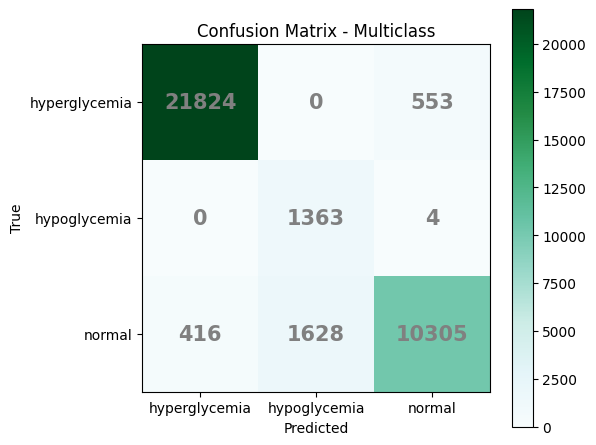

In [86]:
plt.figure(figsize = (6, 5))

plt.imshow(cm_df, interpolation = "nearest", cmap = "BuGn")
plt.title("Confusion Matrix - Multiclass")
plt.colorbar()

# axis labels
plt.xticks(range(len(cm_df.columns)), cm_df.columns)
plt.yticks(range(len(cm_df.index)), cm_df.index)

plt.xlabel("Predicted")
plt.ylabel("True")

for i in range(len(cm_df.index)):
  for j in range(len(cm_df.columns)):
    plt.text(j, i, cm_df.iloc[i, j], ha = "center", va = "center", color = "grey", fontweight = "bold", fontsize = 15)

plt.tight_layout()
plt.show()

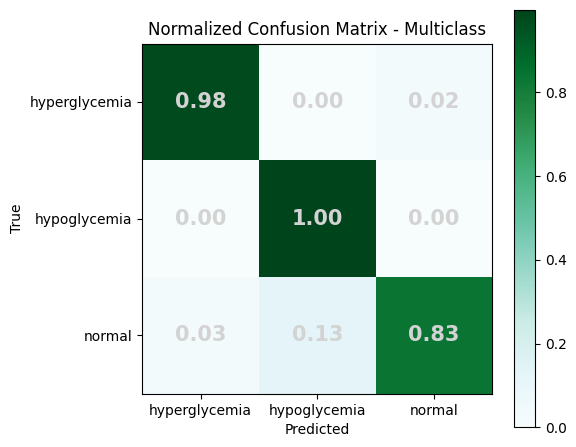

In [87]:
# normalized

cm_norm = cm_df.div(cm_df.sum(axis = 1), axis = 0)

plt.figure(figsize = (6, 5))
plt.imshow(cm_norm, interpolation = "nearest", cmap = "BuGn")
plt.title("Normalized Confusion Matrix - Multiclass")
plt.colorbar()

plt.xticks(range(len(cm_df.columns)), cm_df.columns)
plt.yticks(range(len(cm_df.index)), cm_df.index)

plt.xlabel("Predicted")
plt.ylabel("True")

for i in range(len(cm_df.index)):
  for j in range(len(cm_df.columns)):
    plt.text(j, i, f"{cm_norm.iloc[i, j]:.2f}", ha = "center", va = "center", color = "lightgrey", fontweight = "bold", fontsize = 15)

plt.tight_layout()
plt.show()